### load data 

In [1]:
import pandas as pd

patients = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\patients.csv")
admissions = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\admissions.csv")
icustays = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\icustays.csv")

In [2]:
patients.rename(columns={'subject_id':'patient_id'}, inplace=True)
admissions.rename(columns={'subject_id':'patient_id'}, inplace=True)
icustays.rename(columns={'subject_id':'patient_id'}, inplace=True)

In [3]:
patients.head()

,patient_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [4]:
admissions.head()

,patient_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [5]:
icustays.head()

,patient_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106


In [6]:
ITEM_IDS = {
    220045: "heart_rate",
    220179: "bp",
    220210: "resp_rate",
    223761: "temperature"
}

chunks = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\chartevents.csv", chunksize=500000)

vitals_list = []

for chunk in chunks:
    chunk = chunk[chunk['itemid'].isin(ITEM_IDS.keys())]
    chunk = chunk[['subject_id', 'charttime', 'valuenum', 'itemid']]
    vitals_list.append(chunk)

vitals = pd.concat(vitals_list)
vitals['feature'] = vitals['itemid'].map(ITEM_IDS)

In [7]:
labs = pd.read_csv("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\data\\labevents.csv")

LAB_IDS = {
    50813: "lactate",
    50912: "creatinine",
    51301: "wbc"
}

labs = labs[labs['itemid'].isin(LAB_IDS.keys())]
labs = labs[['subject_id', 'charttime', 'valuenum', 'itemid']]
labs['feature'] = labs['itemid'].map(LAB_IDS)

In [8]:
vitals.rename(columns={'subject_id': 'patient_id'}, inplace=True)
labs.rename(columns={'subject_id': 'patient_id'}, inplace=True)

combined = pd.concat([vitals, labs])
combined['time'] = pd.to_datetime(combined['charttime'])

In [9]:
data = combined.pivot_table(
    index=['patient_id', 'time'],
    columns='feature',
    values='valuenum'
).reset_index()

In [10]:
data.head()

feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc
0,10000032,2180-03-23 11:51:00,NaN,0.4,NaN,NaN,NaN,NaN,3.0
1,10000032,2180-05-06 22:25:00,NaN,0.3,NaN,NaN,NaN,NaN,5.0
2,10000032,2180-05-07 05:05:00,NaN,0.3,NaN,NaN,NaN,NaN,4.2
3,10000032,2180-06-03 12:00:00,NaN,0.4,NaN,NaN,NaN,NaN,NaN
4,10000032,2180-06-22 11:15:00,NaN,0.3,NaN,NaN,NaN,NaN,5.1


In [11]:
data['label'] = (
    (data['bp'] < 90) |
    (data['lactate'] > 2.5) |
    (data['heart_rate'] > 110)
).astype(int)

In [12]:
from sklearn.utils import resample

df_major = data[data.label == 0]
df_minor = data[data.label == 1]

df_minor_up = resample(
    df_minor,
    replace=True,
    n_samples=len(df_major),
    random_state=42
)

data_balanced = pd.concat([df_major, df_minor_up])

In [13]:
print(data['label'].value_counts())

label
0    19622
1     3038
Name: count, dtype: int64


In [14]:
data.head()

feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc,label
0,10000032,2180-03-23 11:51:00,NaN,0.4,NaN,NaN,NaN,NaN,3.0,0
1,10000032,2180-05-06 22:25:00,NaN,0.3,NaN,NaN,NaN,NaN,5.0,0
2,10000032,2180-05-07 05:05:00,NaN,0.3,NaN,NaN,NaN,NaN,4.2,0
3,10000032,2180-06-03 12:00:00,NaN,0.4,NaN,NaN,NaN,NaN,NaN,0
4,10000032,2180-06-22 11:15:00,NaN,0.3,NaN,NaN,NaN,NaN,5.1,0


In [15]:
data = (
    data.sort_values(['patient_id', 'time'])
        .groupby('patient_id', as_index=False)
        .apply(lambda x: x.ffill())
        .reset_index(drop=True)
)

C:\Users\hp\AppData\Local\Temp\ipykernel_8772\2365208375.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.ffill())


In [16]:
# Fill remaining NaNs
data = data.fillna(data.mean())
data.head()

feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc,label
0,10000032,2180-03-23 11:51:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,3.0,0
1,10000032,2180-05-06 22:25:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.0,0
2,10000032,2180-05-07 05:05:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,4.2,0
3,10000032,2180-06-03 12:00:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,4.2,0
4,10000032,2180-06-22 11:15:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.1,0


In [17]:
print(data.isnull().sum())
print(data.shape)
data.head()

feature
patient_id     0
time           0
bp             0
creatinine     0
heart_rate     0
lactate        0
resp_rate      0
temperature    0
wbc            0
label          0
dtype: int64
(22660, 10)


feature,patient_id,time,bp,creatinine,heart_rate,lactate,resp_rate,temperature,wbc,label
0,10000032,2180-03-23 11:51:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,3.0,0
1,10000032,2180-05-06 22:25:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.0,0
2,10000032,2180-05-07 05:05:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,4.2,0
3,10000032,2180-06-03 12:00:00,112.321986,0.4,91.273814,1.949337,20.110023,98.461647,4.2,0
4,10000032,2180-06-22 11:15:00,112.321986,0.3,91.273814,1.949337,20.110023,98.461647,5.1,0


In [18]:
# Prepare patients table
patients_age = patients[['patient_id', 'anchor_age']].copy()


# Merge
data = data.merge(patients_age, on='patient_id', how='left')

# Rename
data.rename(columns={'anchor_age': 'age'}, inplace=True)

In [19]:
print(data.isnull().sum())

patient_id     0
time           0
bp             0
creatinine     0
heart_rate     0
lactate        0
resp_rate      0
temperature    0
wbc            0
label          0
age            0
dtype: int64


In [20]:
features = data[['bp','creatinine','heart_rate','lactate','resp_rate','temperature','wbc','age']]
target = data['label']

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

In [23]:
import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [24]:
import numpy as np
import pandas as pd

SEQ_LENGTH = 24

def create_sequences(features, target, patient_ids):
    X, y = [], []

    df = pd.DataFrame(features)
    df['label'] = target.values
    df['patient_id'] = patient_ids.values

    for pid in df['patient_id'].unique():
        temp = df[df['patient_id'] == pid]

        if len(temp) < SEQ_LENGTH:
            continue  # skip small data (important fix)

        for i in range(len(temp) - SEQ_LENGTH):
            X.append(
                temp.iloc[i:i+SEQ_LENGTH]
                .drop(['label','patient_id'], axis=1)
                .values
            )
            y.append(temp.iloc[i+SEQ_LENGTH]['label'])

    return np.array(X), np.array(y)

X, y = create_sequences(features_scaled, target, data['patient_id'])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20274, 24, 8)
y shape: (20274,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super(LSTMModel, self).__init__()
        
        self.lstm1 = nn.LSTM(input_size, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.lstm2 = nn.LSTM(64, 32, batch_first=True)
        self.fc1 = nn.Linear(32, 16)
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout(out)
        out, _ = self.lstm2(out)
        out = out[:, -1, :]  # last timestep
        out = torch.relu(self.fc1(out))
        out = self.sigmoid(self.fc2(out))
        return out

# Model init
model = LSTMModel(input_size=X.shape[2])
print(model)

LSTMModel(
  (lstm1): LSTM(8, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}

In [29]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.7192 - loss: 0.5680 - val_accuracy: 0.6017 - val_loss: 0.7302
Epoch 2/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.7477 - loss: 0.5191 - val_accuracy: 0.8009 - val_loss: 0.4573
Epoch 3/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.7529 - loss: 0.5043 - val_accuracy: 0.7605 - val_loss: 0.4857
Epoch 4/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.7686 - loss: 0.4858 - val_accuracy: 0.5922 - val_loss: 0.6714
Epoch 5/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.7703 - loss: 0.4786 - val_accuracy: 0.7278 - val_loss: 0.5313
Epoch 6/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.7798 - loss: 0.4647 - val_accuracy: 0.7167 - val_loss: 0.5293
Epoch 7/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.7689 - loss: 0.4629 - val_accuracy: 0.7401 - val_loss: 0.4925
Epoch 8/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.7705 - loss: 0.4593 - 

In [30]:
loss, acc = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8143 - loss: 0.4096
Test Loss: 0.40957915782928467
Test Accuracy: 0.8143033385276794


In [37]:
pred = model.predict(X_test)

# Convert probabilities to 0/1
pred_labels = (pred > 0.5).astype(int)

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, pred_labels))
print(classification_report(y_test, pred_labels))

[[2832  631]
 [ 122  470]]
              precision    recall  f1-score   support

         0.0       0.96      0.82      0.88      3463
         1.0       0.43      0.79      0.56       592

    accuracy                           0.81      4055
   macro avg       0.69      0.81      0.72      4055
weighted avg       0.88      0.81      0.83      4055



In [39]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, pred)
print("AUROC:", auc)

AUROC: 0.8751538952322233


In [40]:
model.save("C:\\Users\\hp\\Desktop\\Septic_shock_prediction\\model\\septic_model.keras")

In [41]:
def predict_risk(sample):
    sample = sample.reshape(1, X.shape[1], X.shape[2])
    prob = model.predict(sample)[0][0]

    if prob > 0.5:
        print(f"⚠️ High Risk: {prob:.2f}")
    else:
        print(f"✅ Low Risk: {prob:.2f}")
        

In [42]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(model.history['accuracy'])
plt.plot(model.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

NameError: name 'history' is not defined

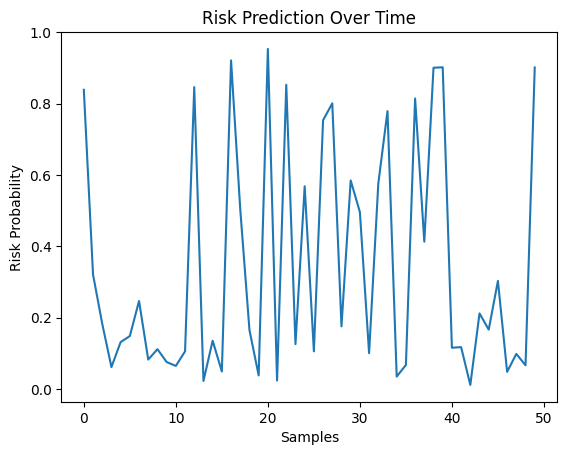

In [43]:
plt.plot(pred[:50])
plt.title("Risk Prediction Over Time")
plt.xlabel("Samples")
plt.ylabel("Risk Probability")
plt.show()

In [ ]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))